## How well do jobs and skills pay for Data Engineers?

#### Methology
1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Engineer
3. Visualize for highest paying and most demanded skills 

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib import cm
import ast
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\david\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_Ger = df[df['job_country'] == 'Germany'].dropna(subset=['salary_year_avg']) 

In [6]:
job_titles = df_Ger['job_title_short'].value_counts().index[:6].tolist()
job_titles

['Data Analyst',
 'Data Scientist',
 'Data Engineer',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [7]:
job_ger_top5 = df_Ger[df_Ger['job_title_short'].isin(job_titles)]

In [18]:
job_order = job_ger_top5.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index


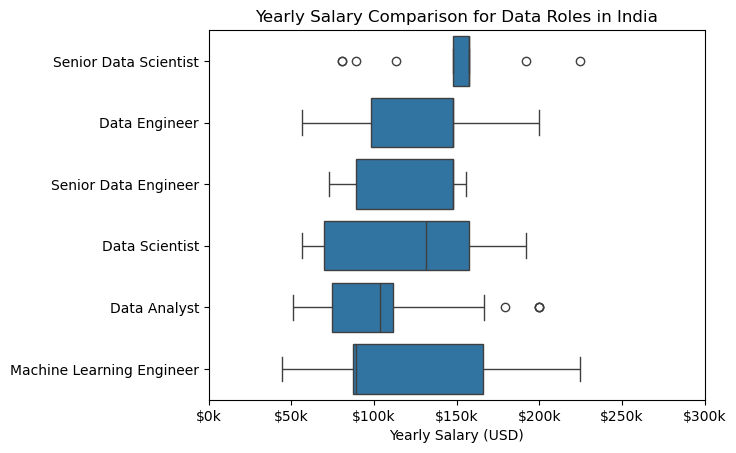

In [20]:
sns.boxplot(data=job_ger_top5, x='salary_year_avg', y='job_title_short', order=job_order)
plt.title('Yearly Salary Comparison for Data Roles in India')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 300000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.show()